SECTION 1 Setup

In [75]:
!pip install scikit-surprise -q

In [76]:
import pandas as pd
import numpy as np

from tqdm import tqdm

from surprise import Dataset
from surprise import Reader
from surprise import SVD

import matplotlib.pyplot as plt

SECTION 2 Load Data

(Load fixed train-test split)

In [77]:
train_df = pd.read_csv(
    "train_per_user_temporal.csv"
)

test_df = pd.read_csv(
    "test_per_user_temporal.csv"
)

print(train_df.shape)
print(test_df.shape)

(1506935, 4)
(493065, 4)


SECTION 3 Train Best Model

(Train tuned SVD model)

In [78]:
reader = Reader(
    rating_scale=(1,5)
)

data = Dataset.load_from_df(
    train_df[
        [
            "user_id",
            "movie_id",
            "rating"
        ]
    ],
    reader
)

trainset = data.build_full_trainset()

In [79]:
svd_model = SVD(
    n_factors=100,
    n_epochs=50,
    lr_all=0.003,
    reg_all=0.05,
    random_state=42
)

In [80]:
svd_model.fit(trainset)

SECTION 4 Generate Predictions

(Predict ratings for test interactions)

In [81]:
predictions = []

for row in tqdm(
    test_df.itertuples(),
    total=len(test_df)
):

    pred = svd_model.predict(
        row.user_id,
        row.movie_id
    )

    predictions.append(
        pred.est
    )

100%|██████████| 493065/493065 [00:03<00:00, 125778.86it/s]


In [82]:
eval_df = test_df.copy()

eval_df[
    "predicted_rating"
] = predictions

SECTION 5 Define Relevance

How well does the recommender rank movies that users actually liked?

In [83]:
eval_df["relevant"] = (
    eval_df["rating"] >= 4
).astype(int)

In [84]:
eval_df["relevant"].value_counts()

,count
relevant,
1,281916
0,211149


In [85]:
precision_scores = []

In [86]:
user_test_counts = (
    eval_df
    .groupby("user_id")
    .size()
)

valid_users = user_test_counts[
    user_test_counts >= 10
].index

eval_df_filtered = eval_df[
    eval_df["user_id"].isin(valid_users)
]

print("Original Users:", eval_df["user_id"].nunique())
print("Filtered Users:", eval_df_filtered["user_id"].nunique())
print("Rows:", len(eval_df_filtered))

Original Users: 266936
Filtered Users: 856
Rows: 10963


In [87]:
for user_id, group in tqdm(
    eval_df_filtered.groupby("user_id")
):

    group = group.sort_values(
        "predicted_rating",
        ascending=False
    )

    top10 = group.head(10)

    if len(top10) == 0:
        continue

    precision = (
        top10["relevant"].sum()
        /
        len(top10)
    )

    precision_scores.append(
        precision
    )

100%|██████████| 856/856 [00:00<00:00, 1944.05it/s]


In [88]:
precision_at_10 = np.mean(
    precision_scores
)

print(
    "Precision@10:",
    round(
        precision_at_10,
        4
    )
)

Precision@10: 0.4367


SECTION 6 Active User Filtering

(Evaluate only users with sufficient test interactions)

In [89]:
user_test_counts = (
    eval_df
    .groupby("user_id")
    .size()
)

valid_users = user_test_counts[
    user_test_counts >= 10
].index

eval_df_filtered = eval_df[
    eval_df["user_id"].isin(valid_users)
]

print(
    "Original Users:",
    eval_df["user_id"].nunique()
)

print(
    "Filtered Users:",
    eval_df_filtered["user_id"].nunique()
)

print(
    "Filtered Rows:",
    len(eval_df_filtered)
)

Original Users: 266936
Filtered Users: 856
Filtered Rows: 10963


SECTION 7 Recall@10

(How many relevant movies are recovered?)

In [90]:
recall_scores = []

In [91]:
for user_id, group in tqdm(
    eval_df_filtered.groupby("user_id")
):

    relevant_items = (
        group["relevant"]
        .sum()
    )

    if relevant_items == 0:
        continue

    group = group.sort_values(
        "predicted_rating",
        ascending=False
    )

    top10 = group.head(10)

    recall = (
        top10["relevant"].sum()
        /
        relevant_items
    )

    recall_scores.append(
        recall
    )

100%|██████████| 856/856 [00:00<00:00, 1861.72it/s]


In [92]:
recall_at_10 = np.mean(
    recall_scores
)

print(
    "Recall@10:",
    round(
        recall_at_10,
        4
    )
)

Recall@10: 0.8977


SECTION 8 MAP@10

(Ranking quality metric)

In [93]:
def apk(
    actual,
    predicted,
    k=10
):

    score = 0.0
    hits = 0

    for i, p in enumerate(
        predicted[:k]
    ):

        if p in actual:

            hits += 1

            score += (
                hits
                /
                (i + 1)
            )

    if len(actual) == 0:
        return 0

    return score / min(
        len(actual),
        k
    )

In [94]:
map_scores = []

In [95]:
for user_id, group in tqdm(
    eval_df_filtered.groupby("user_id")
):

    actual = set(
        group[
            group["relevant"] == 1
        ]["movie_id"]
    )

    predicted = list(
        group.sort_values(
            "predicted_rating",
            ascending=False
        )["movie_id"]
    )

    map_scores.append(
        apk(
            actual,
            predicted,
            k=10
        )
    )

100%|██████████| 856/856 [00:00<00:00, 1245.30it/s]


In [96]:
map_at_10 = np.mean(
    map_scores
)

print(
    "MAP@10:",
    round(
        map_at_10,
        4
    )
)

MAP@10: 0.5971


SECTION 9 Results Summary

(Compare ranking metrics)

In [97]:
results = pd.DataFrame({

    "Metric":[
        "Precision@10",
        "Recall@10",
        "MAP@10"
    ],

    "Score":[
        precision_at_10,
        recall_at_10,
        map_at_10
    ]
})

results

,Metric,Score
0,Precision@10,0.436682
1,Recall@10,0.897737
2,MAP@10,0.597109


SECTION 10 Visualization

(Visualize ranking performance)

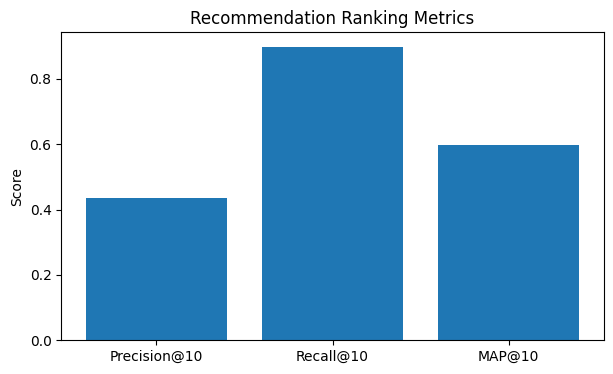

In [98]:
plt.figure(figsize=(7,4))

plt.bar(
    results["Metric"],
    results["Score"]
)

plt.title(
    "Recommendation Ranking Metrics"
)

plt.ylabel(
    "Score"
)

plt.show()